# Text Module Tutorial: Preprocessing & Classification

The `pvops.text.preprocess` submodule offers its primary functionality through the `preprocessor()` function. This function takes a `DataFrame` as input. This dataframe must have at least a column that stores text log and a column that stores the associated datetimes. The function then performs three primary steps:

1. Removes from the text column any numbers which might be confused for dates using `pvops.text.preprocess.text_remove_nondate_nums()`.

2. Extracts dates using `pvops.text.preprocess.get_dates()`, considering both the text column and the datetime column, and only extracting dates after performing some basic quality control checks.

3. Cleans the text data, removing numbers as well as any stopwords passed into the function's `lst_stopwords` argument using `pvops.text.preprocess.text_remove_numbers_stopwords()`.

In [ ]:
# basic manipulation and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# machine learning imports
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import metrics
from gensim.models.doc2vec import Doc2Vec

# pvops functionality
from pvops.text import utils as text_utils
from pvops.text import nlp_utils as text_nlp_utils
from pvops.text import visualize as text_visualize
from pvops.text import preprocess as text_preprocess
from pvops.text import defaults as text_defaults
from pvops.text import classify as text_classify

## Text processing 

### Import text data

In [51]:
df = pd.read_csv('example_data/example_ML_ticket_data.csv')
df.head(5)

,Date_EventStart,Date_EventEnd,Asset,CompletionDesc,Cause,ImpactLevel,randid
0,8/16/2018 9:00,8/22/2018 17:00,Combiner,cb 1.18 was found to have contactor issue woul...,0000 - Unknown.,Underperformance,38
1,9/17/2018 18:25,9/18/2018 9:50,Pad,self resolved. techdispatched: no,004 - Under voltage.,Underperformance,46
2,8/26/2019 9:00,11/5/2019 17:00,Facility,"all module rows washed, waiting for final repo...",0000 - Unknown,Underperformance,62
3,11/14/2017 7:46,11/14/2017 8:35,Inverter,14 nov: we were alerted that e-c3-1 had faulte...,019 - Unplanned outage/derate.,Underperformance,54
4,4/27/2019 9:00,5/2/2019 17:00,Facility,assessed condition filters all inverters. litt...,.,NaN,45


### Initial data cleaning and exploration

Before performing text analysis, it may be necessary to clean up categorical labels to make the data easier to work with. `example_data/remappings_asset.csv` has a helpful mapping for us for the `'Asset'` column, and `pvops.text.utils` offers a function `remap_attributes` to help us perform this remapping.

In [52]:
remapping_df = pd.read_csv('example_data/remappings_asset.csv')
remapping_df.head()

,in,out_
0,inverter,inverter
1,recloser,recloser
2,transformer,transformer
3,switchgear,switchgear
4,combiner,combiner


In [53]:
remapping_col_dict = {
    'attribute_col': 'Asset',
    'remapping_col_from': 'in',
    'remapping_col_to': 'out_'
}

df = text_utils.remap_attributes(df.iloc[30:].copy(), remapping_df.iloc[20:].copy(), remapping_col_dict, allow_missing_mappings=True)
df['Asset'].value_counts()

Asset
inverter                  26
facility                  24
tracker                    6
combiner                   4
other                      2
substation                 2
transformer                1
ground-mount pv system     1
energy storage             1
energy meter               1
met station                1
pyranometer                1
Name: count, dtype: int64

Let's obtain a basic summary of the asset labels using `pvops.nlp_utils.summarize_text_data`. We can also plot the distibution of asset labels over time.

DETAILS
  70 samples
  0 invalid documents
  1.07 words per sample on average
  Number of unique words 16
  75.00 total words


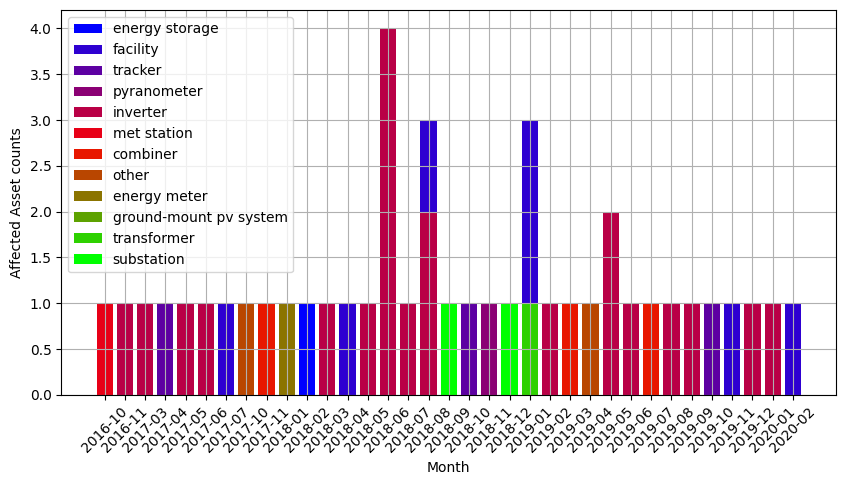

In [54]:
text_nlp_utils.summarize_text_data(df, 'Asset')

df_to_plot = df.copy()
df_to_plot['Date_EventStart'] = pd.to_datetime(df['Date_EventStart'])
df_to_plot = df_to_plot.loc[df_to_plot['Date_EventStart'].notnull()]

_, ax = plt.subplots(figsize=(10,5))
text_visualize.visualize_attribute_timeseries(df_to_plot, dict(date='Date_EventStart', label='Asset'), ax=ax);

Sometimes, a row may be missing the date in the appropriate timestamp column, but dates may still be provided in textual columns. In a case like this, we can use the `preprocessor` function in `pvops.text.preprocess` to extract these dates. Note this function isn't 100% perfect, but should provide a good first pass attempt.

In [55]:
col_dict = dict(data='CompletionDesc',
                eventstart='Date_EventStart',
                save_data_column='CleanDesc',
                save_date_column='ExtractedDates')

dates_df = text_preprocess.preprocessor(df, None, col_dict, extract_dates_only=True)
dates_df.head()[['CompletionDesc', 'ExtractedDates']]

,CompletionDesc,ExtractedDates
0,8/39/19 inverter was faulted with lp15 (low pr...,[2019-08-17 07:35:00]
1,"11,july 2018 -upon arrival w-a6-2, inverter is...","[2018-07-11 18:55:00, 2018-06-02 18:55:00, 201..."
2,arrived site checked into c4. i was able to pi...,[2020-05-26 14:45:00]
3,c4 closed site remotely. techdispatched: no,[]
4,inspection troubleshooting malfunctioning trac...,[]


The `preprocessor` function also has the ability to leverage a list of stopwords to prepare a corpus for ML methods. Here is an example below:

In [58]:
# drop null rows
preprocessed_df = df.copy().dropna(subset=['Asset', 'CompletionDesc'])

# let's only keep asset labels which have more than one instance in the dataset
label_counts = preprocessed_df.value_counts('Asset')
labels_with_multiple_occurrences = label_counts.loc[label_counts > 1].index
preprocessed_df = preprocessed_df.loc[preprocessed_df['Asset'].isin(labels_with_multiple_occurrences)]

# bulid a custom set of stopwords
stopwords = text_nlp_utils.create_stopwords(lst_add_words=['dtype', 'say', 'length', 'object', 'u', 'ha', 'wa'])

# run our preprocessing function to clean up the text data and prepare it for ML
preprocessed_df = text_preprocess.preprocessor(preprocessed_df, stopwords, col_dict)
preprocessed_df.head()[['CompletionDesc', 'CleanDesc']]

,CompletionDesc,CleanDesc
0,8/39/19 inverter was faulted with lp15 (low pr...,inverter faulted lp low pressure inverter show...
1,"11,july 2018 -upon arrival w-a6-2, inverter is...",july upon arrival w inverter running fault lig...
2,arrived site checked into c4. i was able to pi...,arrived site checked able ping inverters local...
3,c4 closed site remotely. techdispatched: no,closed site remotely techdispatched
4,inspection troubleshooting malfunctioning trac...,inspection troubleshooting malfunctioning trac...


pvOps provides a few different ways of exploring how these preprocessing steps have modified the dataset. To start, we can see a set of simple statistics pre- and post-preprocessing:

In [59]:
print('Pre-text processing:')
text_nlp_utils.summarize_text_data(df, 'CompletionDesc')

print('\nPost-text processing')
text_nlp_utils.summarize_text_data(preprocessed_df, 'CleanDesc');

Pre-text processing:
DETAILS
  70 samples
  0 invalid documents
  29.16 words per sample on average
  Number of unique words 881
  2041.00 total words

Post-text processing
DETAILS
  64 samples
  0 invalid documents
  17.30 words per sample on average
  Number of unique words 488
  1107.00 total words


We can also consider embeddings of our documents and quantify how distinct they are from each other. The function `pvops.text.visualize.visualize_cluster_entropy` will compute the Doc2Vec embedding of each row, cluster the embeddings using KMeans, and plot the sum-of-square distance from the embeddings to their respective cluster centroids (known as "inertia" in the context of KMeans).

The resulting plot below demonstrates that the embeddings of the cleaned descriptions are much more "distinct", in the sense that they are further apart in embedding space and hence easier to differentiate.

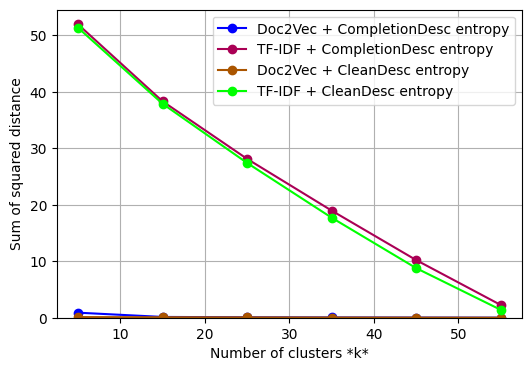

In [60]:
doc2vec_model = Doc2Vec(vector_size=40, min_count=2)
k_vals = np.arange(5, 56, 10)
eval_kmeans = lambda X, k: KMeans(n_clusters=k, n_init=5).fit(X)

_, ax = plt.subplots(figsize=(6,4))
text_visualize.visualize_cluster_entropy(doc2vec_model, eval_kmeans, preprocessed_df, ['CompletionDesc', 'CleanDesc'], k_vals, cmap_name='brg', ax=ax);

We can also, for instance, extract the documents labeled with an "inverter" asset and plot the frequency of the most commonly occuring words in the raw description, and then the cleaned one:

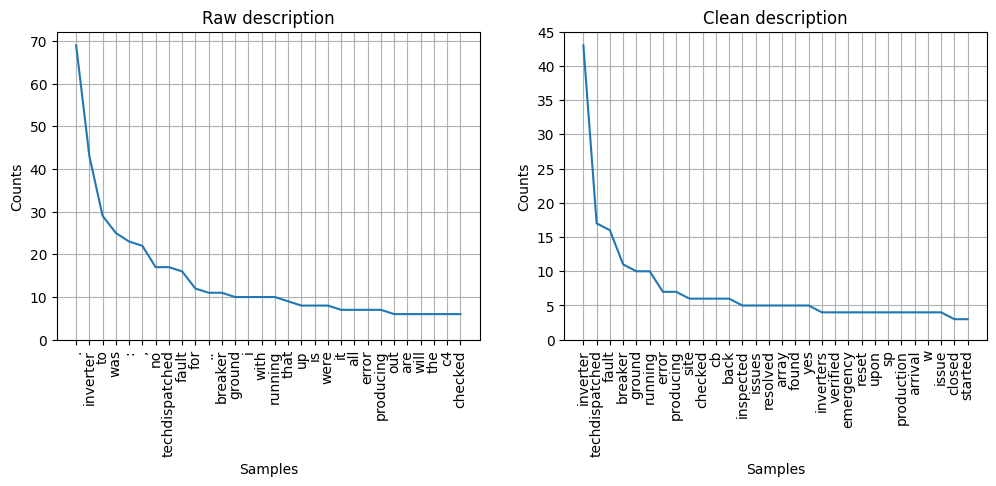

In [61]:
inverter_documents_raw = preprocessed_df.loc[preprocessed_df['Asset'] == 'inverter', 'CompletionDesc']
tokenized_raw = text_preprocess.regex_tokenize(' '.join(inverter_documents_raw))

inverter_documents_clean = preprocessed_df.loc[preprocessed_df['Asset'] == 'inverter', 'CleanDesc']
tokenized_clean = text_preprocess.regex_tokenize(' '.join(inverter_documents_clean))

_, axes = plt.subplots(ncols=2, figsize=(12,4))
text_visualize.visualize_word_frequency_plot(tokenized_raw, 'Raw description', ax=axes[0]);
text_visualize.visualize_word_frequency_plot(tokenized_clean, 'Clean description', ax=axes[1]);

Finally, using the `pvops.text.visualize.visualize_attribute_connectivity` function, we can plot the correspondence between two columns in our dataset. Below, we can qualitatively see how often each asset type (the top row) is associated with each impact level (the bottom row).

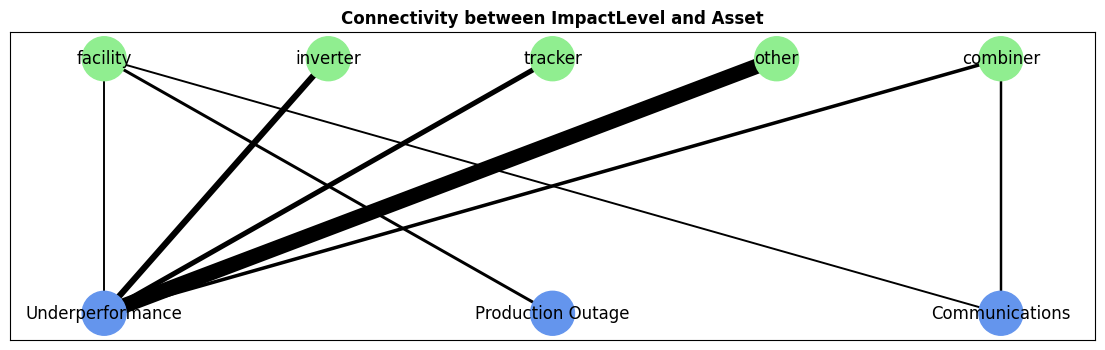

In [62]:
attributes_dict = dict(attribute1_col='Asset', attribute2_col='ImpactLevel')
filtered_df = preprocessed_df.dropna(subset=attributes_dict.values())

_, ax = plt.subplots(figsize=(14,4))
text_visualize.visualize_attribute_connectivity(filtered_df, attributes_dict, ax=ax, graph_aargs=dict(node_size=1000));

### Supervised classification of tickets using a cross-validated grid search

`pvops.text.classify.classification_deployer` provides an interface for performing classification using cross-validated grid search. It takes several arguments:
- `X` and `y`: the predictors and target variables
- `n_splits`: the number of splits for cross-validation
- `classifiers`: a dict whose values are classifier instances
- `search_space`: a dict whose values are hyperparameters to try for each classifier
- `pipeline_steps`: machine learning pipeline, e.g. document embedding, then classification
- `scoring`: the scoring function used to evaluate predictions
- `verbose`: controls how much is printed

In this example, let's try to predict the asset label given the textual description of the ticket. So we'll set our X and y correspondingly:

In [92]:
X, y = preprocessed_df['CleanDesc'], preprocessed_df['Asset']

Next, we'll define our pipeline and scorer using functionality from scikit-learn:

In [93]:
pipeline_steps = [('tfidf', TfidfVectorizer()), ('clf', None)]
scoring = metrics.make_scorer(metrics.f1_score, average='weighted', pos_label=None)

To help with searching over a wide range of models and parameters, `pvops.text.defaults.supervised_classifier_defs` has a set of pre-selected models and hyperameters. We can call it with the `'light'` argument to get a small grid to search over. We can also add some arguments to pass to the vectorizer step in our pipeline.

In [94]:
search_space, classifiers = text_defaults.supervised_classifier_defs('light')
for model_label in search_space.keys():
    search_space[model_label]["tfidf__ngram_range"] = [(1, 3)]
    search_space[model_label]["tfidf__stop_words"] = [None]

We're ready to go ahead and call our classification deployer:

In [95]:
results_df, best_model = text_classify.classification_deployer(
    X=X,
    y=y,
    n_splits=2,
    classifiers=classifiers,
    search_space=search_space,
    pipeline_steps=pipeline_steps,
    scoring=scoring,
    verbose=0,
)

Now, let's take a look at the result. We can print the best model, or take a look at the whole set of models and their performance:

In [96]:
print(best_model)

# organize columns
cols = ["estimator", "min_score", "mean_score", "max_score", "std_score", "mean_fit_time"]
cols += [c for c in results_df.columns if c not in cols]
results_df = results_df[cols]

# sort values and display top models
results_df = results_df.sort_values("mean_score", ascending=False)
results_df.head()

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 3))),
                ('clf', PassiveAggressiveClassifier(C=0.01))])


,estimator,min_score,mean_score,max_score,std_score,mean_fit_time,clf__criterion,clf__min_samples_leaf,clf__min_samples_split,clf__splitter,tfidf__ngram_range,tfidf__stop_words,clf__C,clf__solver,clf__loss,clf__alpha,clf__n_estimators,clf__max_samples,clf__algorithm,clf__learning_rate
36,PassiveAggressiveClassifier,0.5025,0.520343,0.538185,0.017843,0.029542,NaN,NaN,NaN,NaN,"(1, 3)",None,0.1,NaN,squared_hinge,NaN,NaN,NaN,NaN,NaN
34,PassiveAggressiveClassifier,0.5025,0.520343,0.538185,0.017843,0.037065,NaN,NaN,NaN,NaN,"(1, 3)",None,0.01,NaN,squared_hinge,NaN,NaN,NaN,NaN,NaN
33,PassiveAggressiveClassifier,0.5025,0.520343,0.538185,0.017843,0.033409,NaN,NaN,NaN,NaN,"(1, 3)",None,0.01,NaN,hinge,NaN,NaN,NaN,NaN,NaN
38,PassiveAggressiveClassifier,0.5025,0.51182,0.52114,0.00932,0.024136,NaN,NaN,NaN,NaN,"(1, 3)",None,1.0,NaN,squared_hinge,NaN,NaN,NaN,NaN,NaN
35,PassiveAggressiveClassifier,0.5025,0.51182,0.52114,0.00932,0.026051,NaN,NaN,NaN,NaN,"(1, 3)",None,0.1,NaN,hinge,NaN,NaN,NaN,NaN,NaN


### Unsupervised clustering on tickets using a cross-validated grid search

Suppose we would instead like to cluster tickets based on their embeddings. We can do so using `pvops.text.classify.classification_deployer` again, but instead using the grid provided by `pvops.text.defaults.unsupervised_classifier_defs`:

In [99]:
pipeline_steps = [("tfidf", TfidfVectorizer()), ("to_dense", text_nlp_utils.DataDensifier()), ("clf", None)]
scoring = metrics.make_scorer(metrics.homogeneity_score)

X, y = preprocessed_df['CleanDesc'], preprocessed_df['Asset']
n_clusters = len(y.unique()) # clustering requires a number of clusters as a hyperparameter; we'll match the ground truth number of clusters
search_space, classifiers = text_defaults.unsupervised_classifier_defs('normal', n_clusters)

unsupervised_results, unsupervised_best_model = text_classify.classification_deployer(
    X=X,
    y=y,
    n_splits=2,
    classifiers=classifiers,
    search_space=search_space,
    pipeline_steps=pipeline_steps,
    scoring=scoring,
    verbose=0,
)

And we can take a look at the results again:

In [104]:
print(unsupervised_best_model)

# organize columns
cols = ["estimator", "min_score", "mean_score", "max_score", "std_score", "mean_fit_time"]
cols += [c for c in unsupervised_results.columns if c not in cols]
unsupervised_results = unsupervised_results[cols]

# sort values and display top models
unsupervised_results = unsupervised_results.sort_values("mean_score", ascending=False)
unsupervised_results.head()

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('to_dense', DataDensifier()),
                ('clf', Birch(n_clusters=6))])


,estimator,min_score,mean_score,max_score,std_score,mean_fit_time,clf__damping,clf__max_iter,clf__branching_factor,clf__n_clusters,clf__threshold,clf__init,clf__n_init,clf__bandwidth,clf__bin_seeding
4,Birch,0.31972,0.336804,0.353887,0.017083,0.029271,NaN,NaN,50,6,0.5,NaN,NaN,NaN,NaN
7,Birch,0.31972,0.336804,0.353887,0.017083,0.019424,NaN,NaN,100,6,0.5,NaN,NaN,NaN,NaN
2,AffinityPropagation,0.151867,0.326993,0.502118,0.175126,0.077835,0.9,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,KMeans,0.218403,0.317331,0.416259,0.098928,0.091526,NaN,NaN,NaN,6,NaN,random,50,NaN,NaN
0,AffinityPropagation,0.250119,0.312823,0.375527,0.062704,0.063236,0.5,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We may then want to investigate patterns that the model picked up on. We can take the best-performing model, split the dataset according to its predictions, and plot the word frequencies for each label:

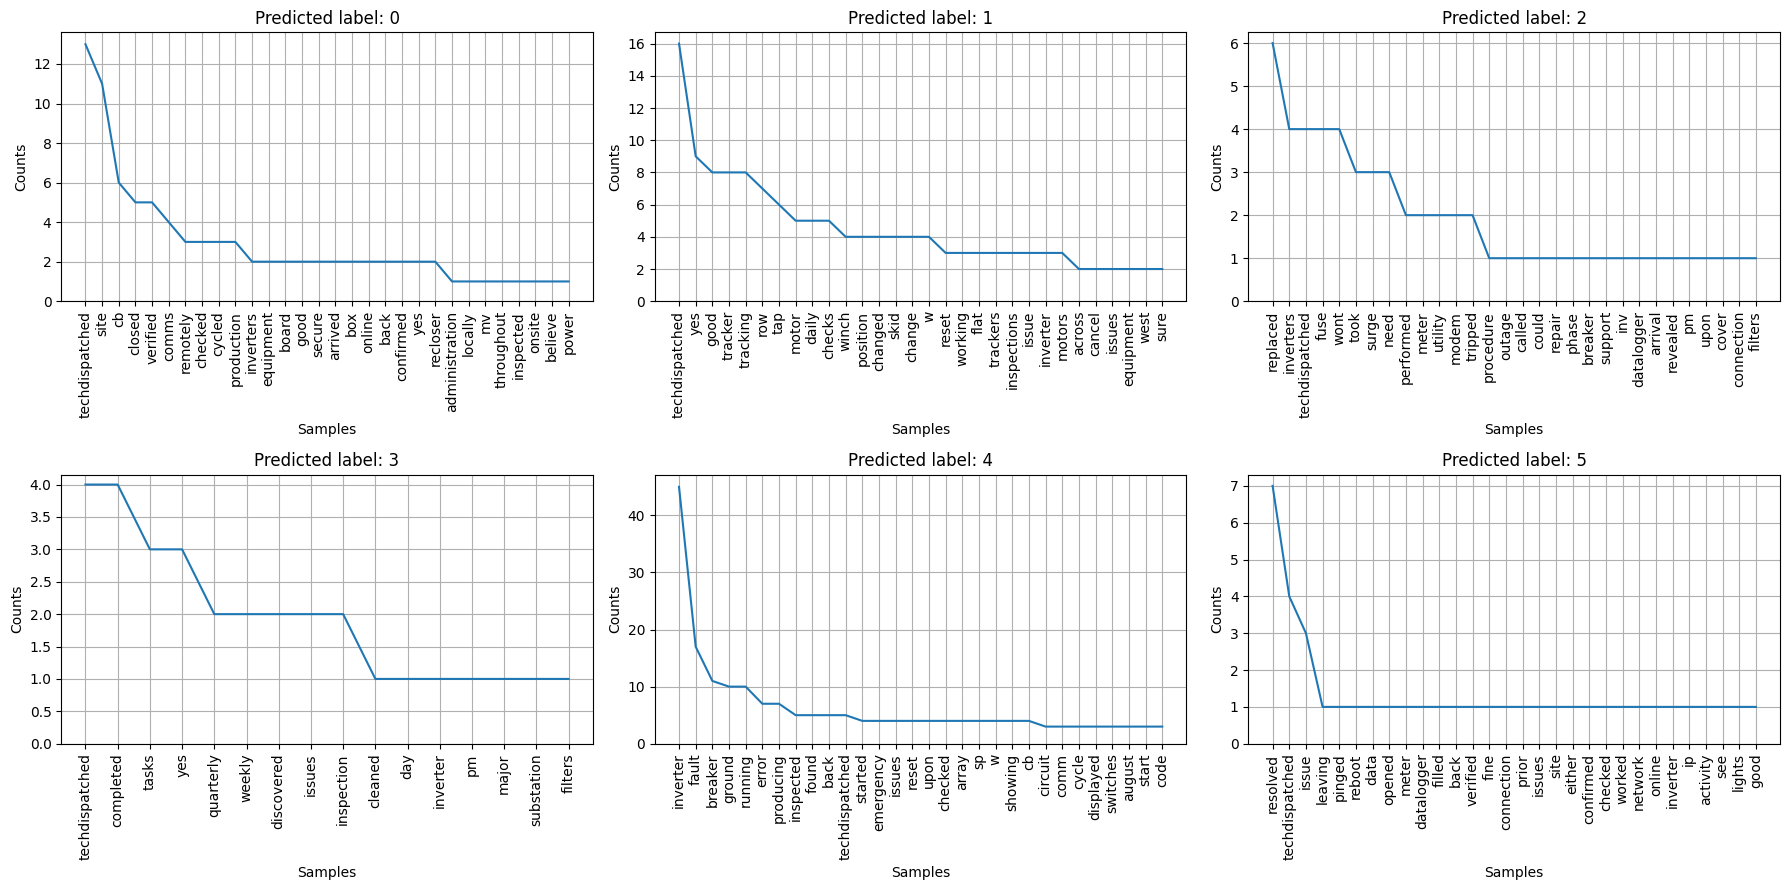

In [124]:
best_model_predictions = unsupervised_best_model.predict(preprocessed_df['CleanDesc'])
labels = np.unique(best_model_predictions)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))

for label, ax in zip(labels, axes.flatten()):
    docs = preprocessed_df.loc[best_model_predictions == label, 'CleanDesc']
    tokenized = text_preprocess.regex_tokenize(' '.join(docs))
    text_visualize.visualize_word_frequency_plot(tokenized, f'Predicted label: {label}', ax=ax);

fig.tight_layout();

Seeing how often `techdispatched` appears across clusters, one might consider adding it to the stopwords list.